# Analysing Laptop Data from Various Vendors

DSAI 103 Final Project - by [Mohsen Elsisi](https://mohsenelsisi.com)


## Setting up

### General Constants


In [6]:
PRODUCT_NAME = "laptop"

### Defining Datastructures


Before defining the actual `Listing` datastructure, the way prices are handled must be managed first,


In [7]:
from typing import Optional
from enum import Enum


class PriceType(Enum):
    DISCRETE = "discrete"
    RANGE = "range"


class PriceValidator:
    def __init__(
        self,
        price_type: PriceType,
        price: Optional[float],
        price_range: Optional[tuple[float, float]],
    ) -> None:
        self.price_type = price_type
        self.price = price
        self.price_range = price_range

    def validate(self):
        match self.price_type:
            case PriceType.DISCRETE:
                self._validate_discrete_price()
            case PriceType.RANGE:
                self._validate_ranged_price()

    def _validate_discrete_price(self):
        if self.price is None:
            raise ValueError("Price cannot be None for discrete price type.")
        if self.price_range is not None:
            raise ValueError(
                f"Price range must be None for discrete price type. "
                f"Received {self.price_range}"
            )
        if self.price < 0.0:
            raise ValueError(
                f"Invalid price. Price cannot be negative. Received {self.price}"
            )

    def _validate_ranged_price(self):
        if self.price is not None:
            raise ValueError(
                f"Price must be None for range price type. Received {self.price}"
            )
        if self.price_range is None:
            raise ValueError("Price range cannot be None for range price type.")
        if self.price_range[0] < 0.0 or self.price_range[1] < 0.0:
            raise ValueError("Invalid price range. Price cannot be negative")
        if self.price_range[0] > self.price_range[1]:
            raise ValueError(
                "Invalid price range. Minimum price cannot be "
                "greater than maximum price"
            )

Then, we define the listing data structure, which represents a single product post on any shopping platform.


In [8]:
from dataclasses import dataclass


@dataclass(frozen=True)
class Listing:
    name: str
    url: str
    image: str

    price_type: PriceType
    price: Optional[float]
    price_range: Optional[tuple[float, float]]

    vendor: str
    subvendor: Optional[str]

    rating: Optional[float]
    review_count: Optional[int]

    def __post_init__(self):
        PriceValidator(self.price_type, self.price, self.price_range).validate()
        if self.rating is not None:
            if self.rating > 5.0 or self.rating < 0.0:
                raise ValueError(
                    f"Invalid rating {self.rating}. Rating must be between 0 and 5"
                )

We also need a utility function to transform a list of `Listing` into a `DataFrame`


In [9]:
from dataclasses import asdict
import pandas as pd


def listing_to_dataframe(listings: list[Listing]) -> pd.DataFrame:
    rows = [asdict(listing) for listing in listings]
    for row in rows:
        if row["price_type"] != None:
            row["price_type"] = row["price_type"].value
    df = pd.DataFrame(rows)
    return df

serialisation is also useful

In [10]:
def listing_to_json(listing: Listing) -> dict:
    data = asdict(listing)
    data["price_type"] = data["price_type"].value
    return data


def listing_from_json(data: dict) -> Listing:
    data["price_type"] = PriceType(data["price_type"])
    if data.get("price_range") is not None:
        data["price_range"] = tuple(data["price_range"])
    return Listing(**data)

## Scraping

This section handles actually scraping the data from various plaforms.


In [22]:
listings: list[Listing] = []

We need to define a custom exception thrown when something goes wrong while scraping any onilne platform.


In [23]:
class ScrapeException(Exception):
    def __init__(self, vendor: str, message: str) -> None:
        super().__init__(f"Error scraping {vendor}: {message}")
        self.vendor = vendor
        self.message = message

### Scraping Ebay


First, the API key is loaded from the `.env` file and setup the client.


In [66]:
from os import environ
from dotenv import load_dotenv
from serpapi import Client

load_dotenv()
SERB_API_KEY = environ["SERB_API_KEY"]

client = Client(api_key=SERB_API_KEY)
client

<SerpApi Client>

Then, we execute the search.


In [67]:
api_response = client.search(
    {
        "engine": "ebay",
        "_nkw": PRODUCT_NAME,
    }
)
api_response

{
    "search_metadata": {
        "id": "69f76016db99ecb76bb8ca08",
        "status": "Success",
        "json_endpoint": "https://serpapi.com/searches/rLshfhxVAlJV4BOgTKslrQ/69f76016db99ecb76bb8ca08.json",
        "created_at": "2026-05-03 14:47:50 UTC",
        "processed_at": "2026-05-03 14:47:50 UTC",
        "ebay_url": "https://www.ebay.com/sch/i.html?_nkw=laptop",
        "raw_html_file": "https://serpapi.com/searches/rLshfhxVAlJV4BOgTKslrQ/69f76016db99ecb76bb8ca08.html",
        "total_time_taken": 2.31
    },
    "search_parameters": {
        "engine": "ebay",
        "_nkw": "laptop"
    },
    "search_information": {
        "organic_results_state": "Results for exact spelling",
        "total_results": 220000,
        "query_displayed": "laptop"
    },
    "categories": [
        {
            "name": "All"
        },
        {
            "id": 58058,
            "name": "Computers/Tablets & Networking"
        },
        {
            "id": 175672,
            "name": "

Lastly, we parse the api response and add its contents to the main list


In [68]:
def parse_ebay_listing(listing_data: dict) -> Listing:
    price_type, price, price_range = parse_ebay_price(listing_data)
    return Listing(
        name=listing_data["title"],
        url=listing_data["link"],
        image=listing_data["thumbnail"],
        price_type=price_type,
        price=price,
        price_range=price_range,
        vendor="Ebay",
        subvendor=listing_data["seller"]["username"],
        rating=None,
        review_count=None,
    )


EXCHANGE_RATE = 53.65


def parse_ebay_price(
    listing_data: dict,
) -> tuple[PriceType, float | None, tuple[float, float] | None]:
    unparsed_price: dict = listing_data.get("price", None)

    if unparsed_price is None:
        raise ListingParserException(
            listing_data, f"Listing is missing price field: {listing_data}"
        )

    if "extracted" in unparsed_price:
        return PriceType.DISCRETE, unparsed_price["extracted"] * EXCHANGE_RATE, None

    if "from" in unparsed_price and "to" in unparsed_price:
        return (
            PriceType.RANGE,
            None,
            (
                unparsed_price["from"]["extracted"] * EXCHANGE_RATE,
                unparsed_price["to"]["extracted"] * EXCHANGE_RATE,
            ),
        )

    raise ScrapeException(
        "Ebay", f"unexpected price format returned from surpapi: {unparsed_price}"
    )


class ListingParserException(Exception):
    def __init__(self, listing, message: str) -> None:
        super().__init__(f"Error parsing listing: {message}\n Listing: {listing}")

In [69]:
listings_json: list[dict] = api_response.get("organic_results", [])
ebay_listings = []

for listing_json in listings_json:
    try:
        ebay_listings.append(parse_ebay_listing(listing_json))
    except ListingParserException as e:
        print(e)

listings.extend(ebay_listings)
listing_to_dataframe(ebay_listings).to_csv("data/ebay_listings.csv")
listing_to_dataframe(ebay_listings)

Error parsing listing: Listing is missing price field: {'title': 'Lenovo - IdeaPad Slim 3i 15.6" Full HD Laptop - Intel Processor N150 2024- 8G...', 'subtitle': 'Lenovo', 'link': 'https://www.ebay.com/itm/198171828463?_skw=laptop&itmmeta=01KQQ4YQGWRXC9MEZXGHKRV2VG&hash=item2e23f620ef:g:jbcAAeSwK8Np7KmY&itmprp=enc%3AAQALAAAAwGfYFPkwiKCW4ZNSs2u11xDUnvvnmduZ2kCs8vpChICp55uo7ZqGjSuZiZQP7CcjFMBWwwfS7dHP%2FZqON9jllp2VIi94xh55RKdXQ8xqve5yU3ZTD917gY1eSS3WiPdmwV%2B5e1Ob8wAI%2B5m%2FO%2F4945X8uaMRW%2F6%2FvsaoNN6EmQBbX0wCv5w6gWobEaGcKMv3WTlTtFnUh2O5vlbO%2F2Icx%2BToDDegcKsBhAeL0NV0pKmppWT1LxxSIGc9l29GMvC8IQ%3D%3D%7Ctkp%3ABk9SR_74-uS9Zw', 'serpapi_link': 'https://serpapi.com/search.json?ebay_domain=ebay.com&engine=ebay_product&product_id=198171828463', 'product_id': '198171828463', 'condition': 'Brand New', 'old_price': {'raw': '$399.99', 'extracted': 399.99, 'discount': 'See price'}, 'shipping': 'Free delivery', 'location': 'Located in United States', 'quantity_sold': '292 sold', 'extracted_quantit

,name,url,image,price_type,price,price_range,vendor,subvendor,rating,review_count
0,"Auusda 14"" Laptop, Intel J4125, 8GB RAM, 512GB...",https://www.ebay.com/itm/377025048834?_skw=lap...,https://i.ebayimg.com/images/g/9J0AAeSw~Dpp1fC...,discrete,16094.4635,None,Ebay,auusda,None,None
1,"Dell Latitude 14"" Laptop Computer Intel i5 Up ...",https://www.ebay.com/itm/286601719329?_skw=lap...,https://i.ebayimg.com/images/g/9MoAAeSwmHdpckM...,range,NaN,"(11319.077, 27532.106999999996)",Ebay,discountcomputerdepot,None,None
2,"Dell Latitude 14"" Laptop Computer Intel i7 Up ...",https://www.ebay.com/itm/286865561827?_skw=lap...,https://i.ebayimg.com/images/g/fhcAAeSwcE5p163...,range,NaN,"(17920.709499999997, 33614.943999999996)",Ebay,discountcomputerdepot,None,None
3,"Dell Latitude 5300 Laptop 13.3"" Core i5 8GB RA...",https://www.ebay.com/itm/256714410251?_skw=lap...,https://i.ebayimg.com/images/g/~QwAAeSwQ5pp6YE...,discrete,10589.9735,None,Ebay,discountcomputerdepot,None,None
4,"DELL CHROMEBOOK 3100 4GB RAM,16GB,CHROME OS NO...",https://www.ebay.com/itm/168275183154?_skw=lap...,https://i.ebayimg.com/images/g/cxoAAeSwPD9oYIb...,discrete,1501.6635,None,Ebay,do-all-1,None,None
5,"HP EliteBook x360 1040 G8 14"" | i7-1185G7, 32G...",https://www.ebay.com/itm/366323683839?_skw=lap...,https://i.ebayimg.com/images/g/AOcAAeSwsABp3-H...,discrete,21620.4135,None,Ebay,ingrammicrorefurbished,None,None
6,"Dell Latitude 5510 Laptop - i5-10210U, 8GB RAM...",https://www.ebay.com/itm/276645670644?_skw=lap...,https://i.ebayimg.com/images/g/ttcAAOSwfTJm6eT...,discrete,8584.0000,None,Ebay,juluplus,None,None
7,Dell Latitude Business Laptop PC 13.3” FHD Cor...,https://www.ebay.com/itm/256696935117?_skw=lap...,https://i.ebayimg.com/images/g/7PIAAeSw1URp4ta...,discrete,16204.4460,None,Ebay,discountcomputerdepot,None,None
8,Lenovo IdeaPad Slim 3 15IRU8 15.6'' (256GB SSD...,https://www.ebay.com/itm/406900239223?_skw=lap...,https://i.ebayimg.com/images/g/dSoAAeSw4GNp9qB...,discrete,6974.5000,None,Ebay,electronic_reseller,None,None
9,Dell Latitude 5580 15.6” Laptop Intel i5-7300H...,https://www.ebay.com/itm/206241249529?_skw=lap...,https://i.ebayimg.com/images/g/tvUAAeSw5-9p8qk...,discrete,10139.8500,None,Ebay,techregenx,None,None


### Scraping Jumia


First, we grab the search page for jumia when we search for the product.


In [28]:
from requests import get as http_get
from bs4 import BeautifulSoup

jumia_search_url = (
    f"https://www.jumia.com.eg/catalog/?q={PRODUCT_NAME.replace(' ', '+')}"
)
jumia_search_page_http_res = http_get(jumia_search_url)
jumia_soup = BeautifulSoup(jumia_search_page_http_res.content, "html.parser")
jumia_soup

<!DOCTYPE html>
<html dir="ltr" lang="en"><head><meta charset="utf-8"/><title>Shop All Products @ #1 Online Store - Enjoy Online Shopping @ Best Prices - Jumia Egypt</title><meta content="en_EG" property="og:locale"/><meta content="ar_EG" property="og:locale:alternate"/><meta content="Shop All Products @ #1 Online Store - Enjoy Online Shopping @ Best Prices - Jumia Egypt" name="title"/><meta content="noindex,follow" name="robots"/><meta content="Select Your Favorite Products from Jumia Egypt's Online Store - Start Online Shopping Today for Products of All Kinds! - Fast Delivery - Free Returns" name="description"/><meta content="website" property="og:type"/><meta content="Shop All Products @ #1 Online Store - Enjoy Online Shopping @ Best Prices - Jumia Egypt" property="og:title"/><meta content="Jumia Egypt" property="og:site_name"/><meta content="Select Your Favorite Products from Jumia Egypt's Online Store - Start Online Shopping Today for Products of All Kinds! - Fast Delivery - Free 

Then, we extract the URLs for the individual listings.


In [29]:
product_cards = jumia_soup.select("[data-catalog=true] article")
product_anchors = [card.select_one("a.core") for card in product_cards]
product_paths = [anchor["href"] for anchor in product_anchors if anchor is not None]
jumia_urls = [f"https://www.jumia.com.eg{path}" for path in product_paths]
jumia_urls

['https://www.jumia.com.eg/lenovo-loq-15iax9-laptop-intelr-core-i5-12450hx-12gb-ram-512gb-ssd-nvidiar-geforce-rtxtm-2050-4gb-15.6-fhd-83gs00sked-luna-grey-133581067.html',
 'https://www.jumia.com.eg/asus-vivobook-16-laptop-intelr-coretm-i7-13620h-16gb-ram-512gb-ssd-intel-uhd-graphics-16-fhd-win11-x1605va-oach007w-cool-silver-134214885.html',
 'https://www.jumia.com.eg/hp-14-em0025ne-laptop-amd-ryzentm-5-7520u-8gb-ram-512gb-ssd-amd-radeon-14.0-fhd-win-11-natural-silver-133863315.html',
 'https://www.jumia.com.eg/lenovo-83dv008qed-loq-15irx9-intelr-coretm-i7-13650hx-ram-16gb-512gb-ssd-nvidiarrtx3050-15.6-fhd-luna-grey-119010318.html',
 'https://www.jumia.com.eg/asus-laptop-vivobook-s-15-s5507qa-ma037w-15.6-3k-oled-snapdragon-x-plus-x1p-16gb512gb-ssd-win11-cool-silver-130115896.html',
 'https://www.jumia.com.eg/lenovo-loq-laptop-intel-core-i7-14700hx-24gb-ram-512gb-ssd-nvidiar-geforce-rtxtm-5050-8gb-15.6-fhd-83je00dbed-luna-grey-133585948.html',
 'https://www.jumia.com.eg/hp-victus-15-fb3

In [30]:
pages: list[BeautifulSoup] = []

for url in jumia_urls:
    # Get the page HTML
    res = http_get(url, timeout=3)
    page = BeautifulSoup(res.content, "html.parser")
    pages.append(page)

pages

[<!DOCTYPE html>
 <html dir="ltr" lang="en"><head><meta charset="utf-8"/><title>Loq 15IAX9 Laptop, Intel® Core i5-12450HX, 12GB Ram, 512GB SSD, NVIDIA® GeForce RTX™ 2050 4GB, 15.6" FHD, 83GS00SKED - Luna Grey - Lenovo - Jumia Egypt</title><meta content="en_EG" property="og:locale"/><meta content="ar_EG" property="og:locale:alternate"/><meta content='Loq 15IAX9 Laptop, Intel® Core i5-12450HX, 12GB Ram, 512GB SSD, NVIDIA® GeForce RTX™ 2050 4GB, 15.6" FHD, 83GS00SKED - Luna Grey - Lenovo - Jumia Egypt' name="title"/><meta content="index,follow" name="robots"/><meta content='Get Lenovo Loq 15IAX9 Laptop, Intel® Core i5-12450HX, 12GB Ram, 512GB SSD, NVIDIA® GeForce RTX™ 2050 4GB, 15.6" FHD, 83GS00SKED - Luna Grey online at Jumia and other Lenovo Notebooks at the best price in Egypt  ➤ Enjoy Amazing Offers &amp; Best Prices with Jumia Egypt - Free Returns - Cash on Delivery' name="description"/><meta content="product" property="og:type"/><meta content='Loq 15IAX9 Laptop, Intel® Core i5-12450

In [ ]:
from bs4.element import Tag
from re import search

jumia_listings = []

for page in pages:
    # Extract name and thumbnail
    name = page.select_one("h1").text
    image = page.select_one("div#imgs img")["data-src"]

    # Extract price
    price_match = search(r"EGP [\d,\.]+", page.text)
    price = None
    if price_match is not None:
        price = float(price_match.group().replace("EGP ", "").replace(",", ""))

    # Extract rating
    stars_element = page.select_one(".stars")
    rating = None
    if type(stars_element) == Tag and stars_element.text.endswith("out of 5"):
        rating_text = search(r"[\d.]+", stars_element.text).group(0)
        rating = float(rating_text) if rating_text != "0" else None

    # Extract review count
    anchors = page.select("a")
    try:
        reviews_anchor = [
            anchor
            for anchor in anchors
            if anchor["href"].startswith("/catalog/productratingsreviews")
        ][0]
        review_count = int(
            search(r"[\d,]+", reviews_anchor.text).group().replace(",", "")
        )
    except IndexError:
        review_count = 0 if "No ratings available" in page.text else None

    # Construct the listing
    jumia_listings.append(
        Listing(
            name=name,
            url=url,
            image=image,
            price_type=PriceType.DISCRETE,
            price=price,
            price_range=None,
            vendor="Jumia",
            subvendor=None,
            rating=rating,
            review_count=review_count,
        )
    )

listings.extend(jumia_listings)
listing_to_dataframe(jumia_listings).to_csv("data/jumia_listings.csv")
listing_to_dataframe(jumia_listings)

,name,url,image,price_type,price,price_range,vendor,subvendor,rating,review_count
0,"Lenovo Loq 15IAX9 Laptop, Intel® Core i5-12450...",https://www.jumia.com.eg/asus-vivobook-15-x150...,https://eg.jumia.is/unsafe/fit-in/500x500/filt...,discrete,38999.000,None,Jumia,None,NaN,0
1,"Asus Vivobook 16 Laptop, Intel® Core™ i7-13620...",https://www.jumia.com.eg/asus-vivobook-15-x150...,https://eg.jumia.is/unsafe/fit-in/500x500/filt...,discrete,36399.000,None,Jumia,None,NaN,0
2,"HP 14-em0025ne Laptop AMD Ryzen™ 5 7520U, 8GB ...",https://www.jumia.com.eg/asus-vivobook-15-x150...,https://eg.jumia.is/unsafe/fit-in/500x500/filt...,discrete,25479.000,None,Jumia,None,NaN,0
3,Lenovo 83Dv008Qed-Loq 15Irx9 Intel® Core™ I7-1...,https://www.jumia.com.eg/asus-vivobook-15-x150...,https://eg.jumia.is/unsafe/fit-in/500x500/filt...,discrete,53039.000,None,Jumia,None,NaN,0
4,Asus LapTop Vivobook S 15-S5507QA-MA037W - 15....,https://www.jumia.com.eg/asus-vivobook-15-x150...,https://eg.jumia.is/unsafe/fit-in/500x500/filt...,discrete,92474.001,None,Jumia,None,NaN,0
5,"Lenovo Loq Laptop Intel Core i7-14700HX, 24GB ...",https://www.jumia.com.eg/asus-vivobook-15-x150...,https://eg.jumia.is/unsafe/fit-in/500x500/filt...,discrete,72079.000,None,Jumia,None,NaN,0
6,HP Victus 15-fb3015ne Laptop - AMD Ryzen™ 7-74...,https://www.jumia.com.eg/asus-vivobook-15-x150...,https://eg.jumia.is/unsafe/fit-in/500x500/filt...,discrete,47839.000,None,Jumia,None,NaN,0
7,TAGITOP Flip-Intel Core i5 8th Generation8259U...,https://www.jumia.com.eg/asus-vivobook-15-x150...,https://eg.jumia.is/unsafe/fit-in/500x500/filt...,discrete,26000.004,None,Jumia,None,NaN,0
8,"HP OmniBook 3 Laptop 15-fn0001ne, AMD Ryzen™ A...",https://www.jumia.com.eg/asus-vivobook-15-x150...,https://eg.jumia.is/unsafe/fit-in/500x500/filt...,discrete,38999.000,None,Jumia,None,NaN,0
9,Lenovo Ideapad Slim 5 16IMH9 83DC003UED Intel®...,https://www.jumia.com.eg/asus-vivobook-15-x150...,https://eg.jumia.is/unsafe/fit-in/500x500/filt...,discrete,48469.000,None,Jumia,None,NaN,0


### Scraping Noon

First, we open Noon, and navigate to the search page after having typed the product nae in the search bar


In [32]:
from time import sleep
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys

# Navigating to search page

BASE_URL = "https://www.noon.com/egypt-en"

driver = webdriver.Chrome()

driver.get(BASE_URL)
search_input = driver.find_element(By.ID, "search-input")
search_input.send_keys(PRODUCT_NAME)
search_input.send_keys(Keys.RETURN)
sleep(3)

# Extract listing URLs from search page

PRODUCT_ANCHOR_SELECTOR = '[data-qa="plp-product-box"] a'

anchors = driver.find_elements(By.CSS_SELECTOR, PRODUCT_ANCHOR_SELECTOR)
noon_listing_urls = [anchor.get_attribute("href") for anchor in anchors]

driver.close()

noon_listing_urls

['https://www.noon.com/egypt-en/macbook-air-mgn63-with-13-inch-display-m1-chip-8-core-cpu-and-7-core-gpu-8gb-ram-256gb-ssd-macos-english-arabic-space-grey/N41964615A/p/?o=bf3e37196b557c7b',
 'https://www.noon.com/egypt-en/upgraded-version-envy-x360-convertible-2-in-1-laptop-with-15-6-inch-fhd-ips-display-core-i5-1335u-processer-8gb-ram-512gb-ssd-intel-xe-graphics-windows-11-english-mineral-silver-english-mineral-silver/N70158196V/p/?o=e44bdacfd4eaaa2f',
 'https://www.noon.com/egypt-en/renewed-elitebook-840-g6-laptop-with-14-1-inch-display-core-i5-processor-8gb-ram-256gb-ssd-intel-uhd-graphics-silver/N40339147A/p/?o=c683d16224807f8c',
 'https://www.noon.com/egypt-en/macbook-pro-mde04-14-inch-display-apple-m5-chip-10-core-cpu-and-10-core-gpu-16gb-ram-512gb-ssd-macos-english-keyboard-international-version-english-space-black/N70248386V/p/?o=a323c074d2bd50af',
 'https://www.noon.com/egypt-en/renewed-latitude-5500-laptop-with-15-6-inch-full-hd-display-core-i7-processor-8gb-ram-256gb-ssd-int

The, we visit each one in turn extracting its data.


In [33]:
from typing import Optional
from re import search
from selenium.webdriver.remote.webelement import WebElement
from selenium.webdriver.remote.webdriver import WebDriver
from selenium.common import NoSuchElementException

PRICE_CONTAINER_SELECTOR = '[data-qa="div-price-now"]'
IMAGE_CLASS = "GalleryV2-module-scss-module__hlK6zG__imageMagnify"
RATING_CLASS = "RatingPreviewStarV2-module-scss-module__0_8vQW__text"
REVIEW_COUNT_CLASS = (
    "NoonRatingsBasedOnTitle-module-scss-module__aAM0SW__basedOnInfoCtrLoader"
)
SOLD_BY_CLASS = "PartnerRatingsV2-module-scss-module__1CV-Aa__soldBy"


def extract_listing_from_noon_page(driver: WebDriver):
    name = driver.find_element(By.TAG_NAME, "h1").text

    image = driver.find_element(By.CLASS_NAME, IMAGE_CLASS).get_attribute("src")

    price_container: WebElement = driver.find_element(
        By.CSS_SELECTOR, PRICE_CONTAINER_SELECTOR
    )
    parts = price_container.find_elements(By.XPATH, ".//*")
    price_text = parts[1].text if len(parts) > 1 else price_container.text
    price_match = search(r"[\d,\.]+", price_text)
    price = float(price_match.group(0).replace(",", "")) if price_match else None

    try:
        rating_element = driver.find_element(By.CLASS_NAME, RATING_CLASS)
        rating = float(rating_element.text)
    except NoSuchElementException:
        rating = None

    try:
        review_count_element = driver.find_element(By.CLASS_NAME, REVIEW_COUNT_CLASS)
        review_count_match = search(r"[\d,]+", review_count_element.text)
        review_count = (
            int(review_count_match.group(0).replace(",", ""))
            if review_count_match
            else None
        )
    except NoSuchElementException:
        review_count = None

    try:
        sold_by_element = driver.find_element(By.CLASS_NAME, SOLD_BY_CLASS)
        subvendor = sold_by_element.text
    except NoSuchElementException:
        subvendor = None

    return Listing(
        name=name,
        url=url,
        image=image,
        price_type=PriceType.DISCRETE,
        price=price,
        price_range=None,
        vendor="Noon",
        subvendor=subvendor,
        rating=rating,
        review_count=review_count,
    )

In [ ]:
noon_listings: list[Listing] = []

driver = webdriver.Chrome()

for url in noon_listing_urls:
    driver.get(url)
    sleep(2)
    noon_listings.append(extract_listing_from_noon_page(driver))

driver.close()
 
listings.extend(noon_listings)
listing_to_dataframe(noon_listings).to_csv("data/noon_listings.csv")
listing_to_dataframe(noon_listings)

,name,url,image,price_type,price,price_range,vendor,subvendor,rating,review_count
0,"MacBook Air MGN63 With 13 Inch Display, M1 Chi...",https://www.noon.com/egypt-en/macbook-air-mgn6...,https://f.nooncdn.com/p/pnsku/N41964615A/45/_/...,discrete,38944.99,None,Noon,dtechstore,4.6,None
1,(Upgraded Version) Envy x360 Convertible 2-In-...,https://www.noon.com/egypt-en/upgraded-version...,https://f.nooncdn.com/p/pnsku/N70158196V/45/_/...,discrete,37999.00,None,Noon,Egypt Laptop,5.0,None
2,Renewed EliteBook 840 G6 Laptop With 14.1-Inch...,https://www.noon.com/egypt-en/renewed-eliteboo...,https://f.nooncdn.com/p/v1600075142/N40339147A...,discrete,20900.00,None,Noon,,4.1,None
3,MacBook Pro MDE04 | 14 Inch Display | Apple M5...,https://www.noon.com/egypt-en/macbook-pro-mde0...,https://f.nooncdn.com/p/pnsku/N70248386V/45/_/...,discrete,94998.95,None,Noon,dtechstore,4.5,None
4,Renewed Latitude 5500 Laptop With 15.6-Inch Fu...,https://www.noon.com/egypt-en/renewed-latitude...,https://f.nooncdn.com/p/v1612966237/N41338406A...,discrete,22500.00,None,Noon,,4.0,None
5,MacBook Pro MDE34 | 14 Inch Display | Apple M5...,https://www.noon.com/egypt-en/macbook-pro-mde3...,https://f.nooncdn.com/p/pnsku/N70248384V/45/_/...,discrete,119998.95,None,Noon,Simple,4.5,None
6,(Upgraded Version) EliteBook 840 G8 With 14-In...,https://www.noon.com/egypt-en/upgraded-version...,https://f.nooncdn.com/p/v1649227945/N50854932A...,discrete,32850.00,None,Noon,,2.8,None
7,Renewed Latitude 7480 Laptop With 14-Inch Full...,https://www.noon.com/egypt-en/renewed-latitude...,https://f.nooncdn.com/p/v1649432297/N14163861A...,discrete,17232.00,None,Noon,,4.0,None
8,MacBook Pro MX2H3 | 14.2 Inch Display | Apple ...,https://www.noon.com/egypt-en/macbook-pro-mx2h...,https://f.nooncdn.com/p/pnsku/N70125918V/45/_/...,discrete,111724.00,None,Noon,,4.5,None
9,Renewed Latitude 7490 Laptop With 14-Inch Disp...,https://www.noon.com/egypt-en/renewed-latitude...,https://f.nooncdn.com/p/pnsku/N29602621A/45/_/...,discrete,18000.00,None,Noon,,3.6,None


#### Scraping Copurchased Products

In [35]:
from time import sleep
import networkx as nx
from selenium import webdriver
from selenium.webdriver.remote.webdriver import WebDriver
from selenium.webdriver.remote.webdriver import By
from selenium.common.exceptions import NoSuchElementException
import matplotlib.pyplot as plt

In [36]:
noon_product_graph = nx.Graph()
noon_product_graph.add_nodes_from([listing.url for listing in noon_listings])

In [37]:
def extract_copurchased_products(driver: WebDriver):
    try: 
        product_container = driver.find_element(
            By.CLASS_NAME,
            "FrequentBoughtTogetherV2-module-scss-module__d1b6Qa__emblaContainer",
        )
        return [
            element.get_attribute("href")
            for element in product_container.find_elements(By.TAG_NAME, "a")
        ]
    except NoSuchElementException:
        return []

In [38]:
driver = webdriver.Chrome()

copurchased_product_links: list[list[str]] =  []

for listing in noon_listings:
    driver.get(listing.url)
    sleep(1)
    copurchased_product_links.append(extract_copurchased_products(driver))

driver.close()

copurchased_product_links    

[['https://www.noon.com/egypt-en/product/N41964615A/p/?o=bf3e37196b557c7b',
  'https://www.noon.com/egypt-en/laptop-backpack-large-capacity-school-bag-usb-charging-port-water-resistant-15-6-inch-black/Z69227260D25835AF2A1CZ/p/?o=z69227260d25835af2a1cz-1',
  'https://www.noon.com/egypt-en/mx-master-3s-wireless-performance-mouse-with-ultra-fast-scrolling-graphite/N53335896A/p/?o=aa073aa71047f3eb',
  'https://www.noon.com/egypt-en/redmi-note-15-dual-sim-4g-black-8g-ram-256gb-with-2-pin-adaptor-global-version/N70270908V/p/?o=edc4cd9b834fd3aa'],
 ['https://www.noon.com/egypt-en/product/N70158196V/p/?o=e44bdacfd4eaaa2f',
  'https://www.noon.com/egypt-en/hama-laptop-bag-jersey-port-34-36-cm-13-3-inches-14-1-inches-beige/Z85612879A58AE77E99A6Z/p/?o=e0de6dee9735ed9a',
  'https://www.noon.com/egypt-en/300-wireless-compact-mouse-gy51l15678-arctic-grey/N70032766V/p/?o=cbaaff872217972b',
  'https://www.noon.com/egypt-en/freebuds-se-2-in-ear-earphones-true-wireless-earbuds-40-hour-battery-life-ip54-

In [39]:
copruchased_product_url_map: dict[str, Listing] = {}

driver = webdriver.Chrome()
            
for i, origin_product in enumerate(noon_listings):
    for url in copurchased_product_links[i]:
        if url in copruchased_product_url_map:
            copurchased_product_listing = copruchased_product_url_map[url]
        else:
            driver.get(url)
            sleep(2)
            copurchased_product_listing = extract_listing_from_noon_page(driver)
            copruchased_product_url_map[url] = copurchased_product_listing
        noon_product_graph.add_edge(origin_product.url, url)

driver.close()

copruchased_product_url_map

{'https://www.noon.com/egypt-en/product/N41964615A/p/?o=bf3e37196b557c7b': Listing(name='MacBook Air MGN63 With 13 Inch Display, M1 Chip 8-Core CPU and 7-Core GPU | 8GB RAM | 256GB SSD | macOS | English/Arabic Space Grey', url='https://www.noon.com/egypt-en/product/N41964615A/p/?o=bf3e37196b557c7b', image='https://f.nooncdn.com/p/pnsku/N41964615A/45/_/1768825891/2fa999f6-d509-4599-beeb-0d1350dfba22.jpg?width=800', price_type=<PriceType.DISCRETE: 'discrete'>, price=38944.99, price_range=None, vendor='Noon', subvendor='dtechstore', rating=4.6, review_count=None),
 'https://www.noon.com/egypt-en/laptop-backpack-large-capacity-school-bag-usb-charging-port-water-resistant-15-6-inch-black/Z69227260D25835AF2A1CZ/p/?o=z69227260d25835af2a1cz-1': Listing(name='Laptop Backpack Large Capacity School Bag USB Charging Port Water Resistant 15.6 inch - Black', url='https://www.noon.com/egypt-en/laptop-backpack-large-capacity-school-bag-usb-charging-port-water-resistant-15-6-inch-black/Z69227260D25835A

In [ ]:
import json
with open("data/copurchased_products.json", "w") as json_file:
    serialised_copruchased_product_url_map = {
        url : listing_to_json(listing)
        for url, listing in copruchased_product_url_map.items()
    }
    json.dump(serialised_copruchased_product_url_map, json_file)

nx.write_graphml(noon_product_graph, "data/noon_products.graphml")

## Persisting Scraped Data


### Saving Data to disk

In [84]:
listings = []
listings.extend(ebay_listings)
listings.extend(jumia_listings)
listings.extend(noon_listings)

listings_df = listing_to_dataframe(listings)
listings_df.to_csv("data/listings.csv")
listings_df

,name,url,image,price_type,price,price_range,vendor,subvendor,rating,review_count
0,"Auusda 14"" Laptop, Intel J4125, 8GB RAM, 512GB...",https://www.ebay.com/itm/377025048834?_skw=lap...,https://i.ebayimg.com/images/g/9J0AAeSw~Dpp1fC...,discrete,16094.4635,None,Ebay,auusda,NaN,NaN
1,"Dell Latitude 14"" Laptop Computer Intel i5 Up ...",https://www.ebay.com/itm/286601719329?_skw=lap...,https://i.ebayimg.com/images/g/9MoAAeSwmHdpckM...,range,NaN,"(11319.077, 27532.106999999996)",Ebay,discountcomputerdepot,NaN,NaN
2,"Dell Latitude 14"" Laptop Computer Intel i7 Up ...",https://www.ebay.com/itm/286865561827?_skw=lap...,https://i.ebayimg.com/images/g/fhcAAeSwcE5p163...,range,NaN,"(17920.709499999997, 33614.943999999996)",Ebay,discountcomputerdepot,NaN,NaN
3,"Dell Latitude 5300 Laptop 13.3"" Core i5 8GB RA...",https://www.ebay.com/itm/256714410251?_skw=lap...,https://i.ebayimg.com/images/g/~QwAAeSwQ5pp6YE...,discrete,10589.9735,None,Ebay,discountcomputerdepot,NaN,NaN
4,"DELL CHROMEBOOK 3100 4GB RAM,16GB,CHROME OS NO...",https://www.ebay.com/itm/168275183154?_skw=lap...,https://i.ebayimg.com/images/g/cxoAAeSwPD9oYIb...,discrete,1501.6635,None,Ebay,do-all-1,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
142,(Upgraded Version) Latitude 7420 14 inch Full ...,https://www.noon.com/egypt-en/upgraded-version...,https://f.nooncdn.com/p/v1656599535/N53067340A...,discrete,40650.0000,None,Noon,NaN,3.3,NaN
143,Msi Katana 15 HX 14XWGK Gaming Laptop Intel Co...,https://www.noon.com/egypt-en/msi-katana-15-hx...,https://f.nooncdn.com/p/5c6e95c6bee35f1da03dc4...,discrete,84999.0000,None,Noon,NaN,4.3,NaN
144,Latitude 5300 (Upgraded Version) Laptop With 1...,https://www.noon.com/egypt-en/latitude-5300-up...,https://f.nooncdn.com/p/v1633261332/N51072875A...,discrete,18954.0000,None,Noon,NaN,3.6,NaN
145,MacBook Pro MDE44 | 14 Inch Display | Apple M5...,https://www.noon.com/egypt-en/macbook-pro-mde4...,https://f.nooncdn.com/p/pnsku/N70248383V/45/_/...,discrete,98837.6000,None,Noon,NaN,4.5,NaN


### Loading Data from Disk

In [85]:
from typing import Any
import networkx as nx
import json
from ast import literal_eval
import pandas as pd


def parse_price_range(value: Any):
    if pd.isna(value):
        return None
    if isinstance(value, tuple):
        return value
    if isinstance(value, str):
        value = value.strip().strip("()")
        if not value:
            return None
        left, right = value.split(",")
        return (float(left), float(right))
    return value


def load_listings_csv(path: str) -> list[Listing]:
    df = pd.read_csv(path, index_col=0)

    df["price_type"] = df["price_type"].astype(str)

    df["price_range"] = df["price_range"].apply(
        lambda x: (
            None
            if pd.isna(x)
            else (tuple(literal_eval(x)) if isinstance(x, str) else x)
        )
    )

    df["price"] = df["price"].apply(lambda x: (None if pd.isna(x) else x))

    result = []
    for _, row in df.iterrows():
        row_dict = row.to_dict()
        # Ensure all nullable fields are None, not NaN
        if pd.isna(row_dict.get("price")):
            row_dict["price"] = None
        if pd.isna(row_dict.get("price_range")):
            row_dict["price_range"] = None
        if pd.isna(row_dict.get("rating")):
            row_dict["rating"] = None
        if pd.isna(row_dict.get("review_count")):
            row_dict["review_count"] = None
        if pd.isna(row_dict.get("subvendor")):
            row_dict["subvendor"] = None
        result.append(listing_from_json(row_dict))
    
    return result


ebay_listings = load_listings_csv("data/ebay_listings.csv")
jumia_listings = load_listings_csv("data/jumia_listings.csv")
noon_listings = load_listings_csv("data/noon_listings.csv")

listings = []
listings.extend(ebay_listings)
listings.extend(jumia_listings)
listings.extend(noon_listings)

with open("data/copurchased_products.json", "r") as json_file:
    copruchased_product_url_map = {
        url : listing_from_json(listing_json)
        for url, listing_json in json.load(json_file).items()}

noon_product_graph = nx.read_graphml("data/noon_products.graphml")

listings

[Listing(name='Auusda 14" Laptop, Intel J4125, 8GB RAM, 512GB SSD, W11 for Student & Office', url='https://www.ebay.com/itm/377025048834?_skw=laptop&itmmeta=01KQQ4YQGW0WV8BK148GENBYQK&hash=item57c871b102:g:9J0AAeSw~Dpp1fCb&itmprp=enc%3AAQALAAAAwGfYFPkwiKCW4ZNSs2u11xDN9CH24qHiAmjgBOAaZl1RX18ElV3j32U2gynXmKg5Gq4VqAUYIO5kQpvb0wwQq9srkITy5rJ4zUzNQAhKTOJ7yNVf%2BafqlnFpR%2Bpr5wb%2B4PAI6wR9sb3vOhl7R%2BiBzW%2F2wcHfaoVXzBWp4kVOTmDFluWeoqm8icaLYzdRtXRk7rRgdi%2BYVz1VOfdzIOstFk66aXKjSkQI0W2NjVZZiX7IJQIxDRgc%2BqVewwqPbckxnw%3D%3D%7Ctkp%3ABlBMUPz4-uS9Zw', image='https://i.ebayimg.com/images/g/9J0AAeSw~Dpp1fCb/s-l500.webp', price_type=<PriceType.DISCRETE: 'discrete'>, price=16094.4635, price_range=None, vendor='Ebay', subvendor='auusda', rating=None, review_count=None),
 Listing(name='Dell Latitude 14" Laptop Computer Intel i5 Up To 32GB RAM 1TB SSD Windows 11 Pro', url='https://www.ebay.com/itm/286601719329?_skw=laptop&itmmeta=01KQQ4YQGWBAM455S2RXKPDVD5&hash=item42bacb2e21:g:9MoAAeSwmHdpckMj&itmprp=

## Visualisation and Analysis


In [86]:
import os

os.makedirs("visualisations", exist_ok=True)

### Standardising Prices
Before doing any analysis, we must comvert all price ranges to solid discrete prices. 

In [87]:
from copy import deepcopy

listings_df = listing_to_dataframe(listings)
listing_df_solid_prices = deepcopy(listings_df)

mask = listing_df_solid_prices["price_type"] == PriceType.RANGE.value

listing_df_solid_prices.loc[mask, "price"] = listing_df_solid_prices.loc[
    mask, "price_range"
].apply(lambda r: (r[0] + r[1]) / 2 if r is not None else None)

listing_df_solid_prices = listing_df_solid_prices.drop(
    columns=["price_type", "price_range"]
)

listing_df_solid_prices

,name,url,image,price,vendor,subvendor,rating,review_count
0,"Auusda 14"" Laptop, Intel J4125, 8GB RAM, 512GB...",https://www.ebay.com/itm/377025048834?_skw=lap...,https://i.ebayimg.com/images/g/9J0AAeSw~Dpp1fC...,16094.46350,Ebay,auusda,NaN,NaN
1,"Dell Latitude 14"" Laptop Computer Intel i5 Up ...",https://www.ebay.com/itm/286601719329?_skw=lap...,https://i.ebayimg.com/images/g/9MoAAeSwmHdpckM...,19425.59200,Ebay,discountcomputerdepot,NaN,NaN
2,"Dell Latitude 14"" Laptop Computer Intel i7 Up ...",https://www.ebay.com/itm/286865561827?_skw=lap...,https://i.ebayimg.com/images/g/fhcAAeSwcE5p163...,25767.82675,Ebay,discountcomputerdepot,NaN,NaN
3,"Dell Latitude 5300 Laptop 13.3"" Core i5 8GB RA...",https://www.ebay.com/itm/256714410251?_skw=lap...,https://i.ebayimg.com/images/g/~QwAAeSwQ5pp6YE...,10589.97350,Ebay,discountcomputerdepot,NaN,NaN
4,"DELL CHROMEBOOK 3100 4GB RAM,16GB,CHROME OS NO...",https://www.ebay.com/itm/168275183154?_skw=lap...,https://i.ebayimg.com/images/g/cxoAAeSwPD9oYIb...,1501.66350,Ebay,do-all-1,NaN,NaN
...,...,...,...,...,...,...,...,...
142,(Upgraded Version) Latitude 7420 14 inch Full ...,https://www.noon.com/egypt-en/upgraded-version...,https://f.nooncdn.com/p/v1656599535/N53067340A...,40650.00000,Noon,NaN,3.3,NaN
143,Msi Katana 15 HX 14XWGK Gaming Laptop Intel Co...,https://www.noon.com/egypt-en/msi-katana-15-hx...,https://f.nooncdn.com/p/5c6e95c6bee35f1da03dc4...,84999.00000,Noon,NaN,4.3,NaN
144,Latitude 5300 (Upgraded Version) Laptop With 1...,https://www.noon.com/egypt-en/latitude-5300-up...,https://f.nooncdn.com/p/v1633261332/N51072875A...,18954.00000,Noon,NaN,3.6,NaN
145,MacBook Pro MDE44 | 14 Inch Display | Apple M5...,https://www.noon.com/egypt-en/macbook-pro-mde4...,https://f.nooncdn.com/p/pnsku/N70248383V/45/_/...,98837.60000,Noon,NaN,4.5,NaN


### Relationship between Price and Rating

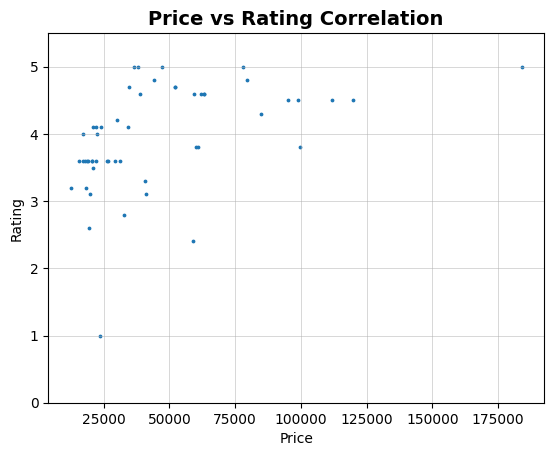

In [96]:
import matplotlib.pyplot as plt
import numpy as np

listings_with_ratings = listing_df_solid_prices[
    listing_df_solid_prices["rating"].notna()
]

plt.scatter(listings_with_ratings["price"], listings_with_ratings["rating"], s=3)
plt.title("Price vs Rating Correlation", fontsize=14, fontweight='bold')
plt.xlabel("Price")
plt.ylabel("Rating")
plt.ylim(0, 5.5)
plt.grid(True, linewidth=0.5, alpha=0.7)
plt.savefig("visualisations/01_price_vs_rating.png", dpi=300, bbox_inches='tight')
plt.show()

We can also Better understand this relationship by checking the correlation coeffecient.

In [89]:
listings_with_ratings["price"].corr(listings_with_ratings["rating"])

np.float64(0.465158412242934)

The above value indicates a **moderate correlation** between price and rating. 

#### Verifying Reliabilty of the Correlation
After seeing the Visualisations, we had doubts about the reliability of its implications, hence we investigate this reliability by examining how much of the data was removed due to having missing rating data and whether there is a relationship between price and the existance of ratings in the first place.

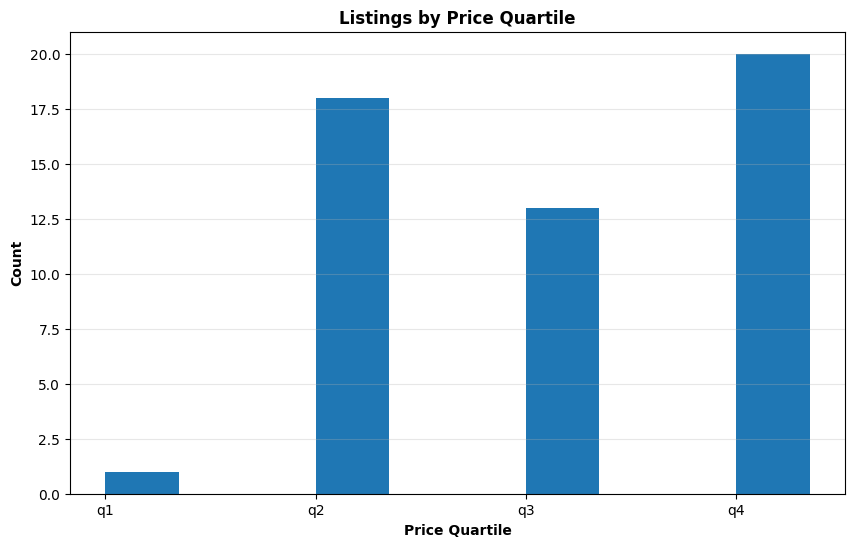

In [90]:
listing_df_solid_prices["price_category"] = pd.qcut(
    listing_df_solid_prices["price"], 4, labels=["q1", "q2", "q3", "q4"]
)

listings_with_ratings = listing_df_solid_prices[
    listing_df_solid_prices["rating"].notna()
]

fig, ax = plt.subplots(figsize=(10, 6))

counts = (
    listings_with_ratings["price_category"]
    .value_counts()
    .reindex(["q1", "q2", "q3", "q4"], fill_value=0)
)

bar_width = 0.35
x = np.arange(len(counts))
ax.bar(x + bar_width/2, counts.values, bar_width, label="rated")
ax.set_xticks(x)
ax.set_xticklabels(counts.index)
ax.set_xlabel("Price Quartile", fontweight='bold')
ax.set_ylabel("Count", fontweight='bold')
ax.set_title("Listings by Price Quartile", fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

With the exception of Q1, the differences between each price quartile seem insignificant, but then we considered comparing that to the unrated listings in each quartile.

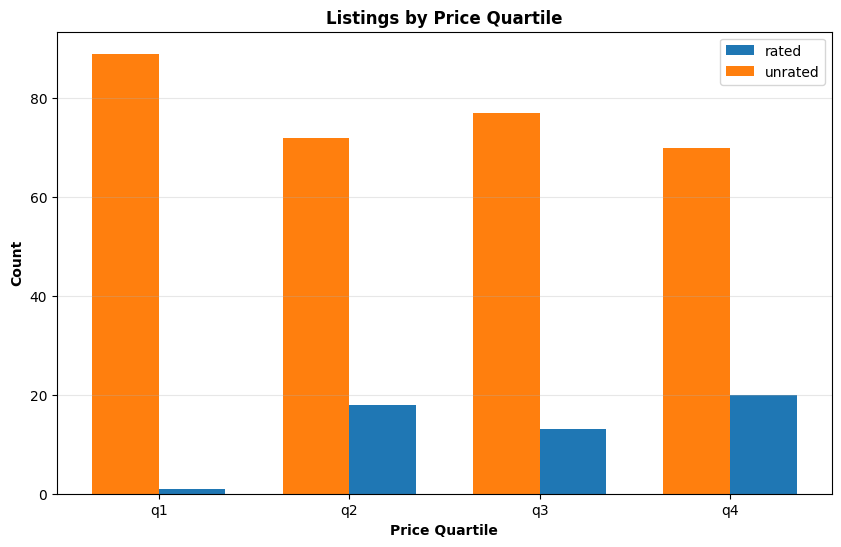

<Figure size 640x480 with 0 Axes>

In [91]:
anti_counts = len(listings_df[listings_df["vendor"] != "Ebay"]) - counts

ax.bar(x - bar_width/2, anti_counts.values, bar_width, label="unrated")
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.savefig("visualisations/02_listings_by_price_quartile.png", dpi=300, bbox_inches='tight')
fig

### Copurchased Products from Noon

#### Visualision the Graph

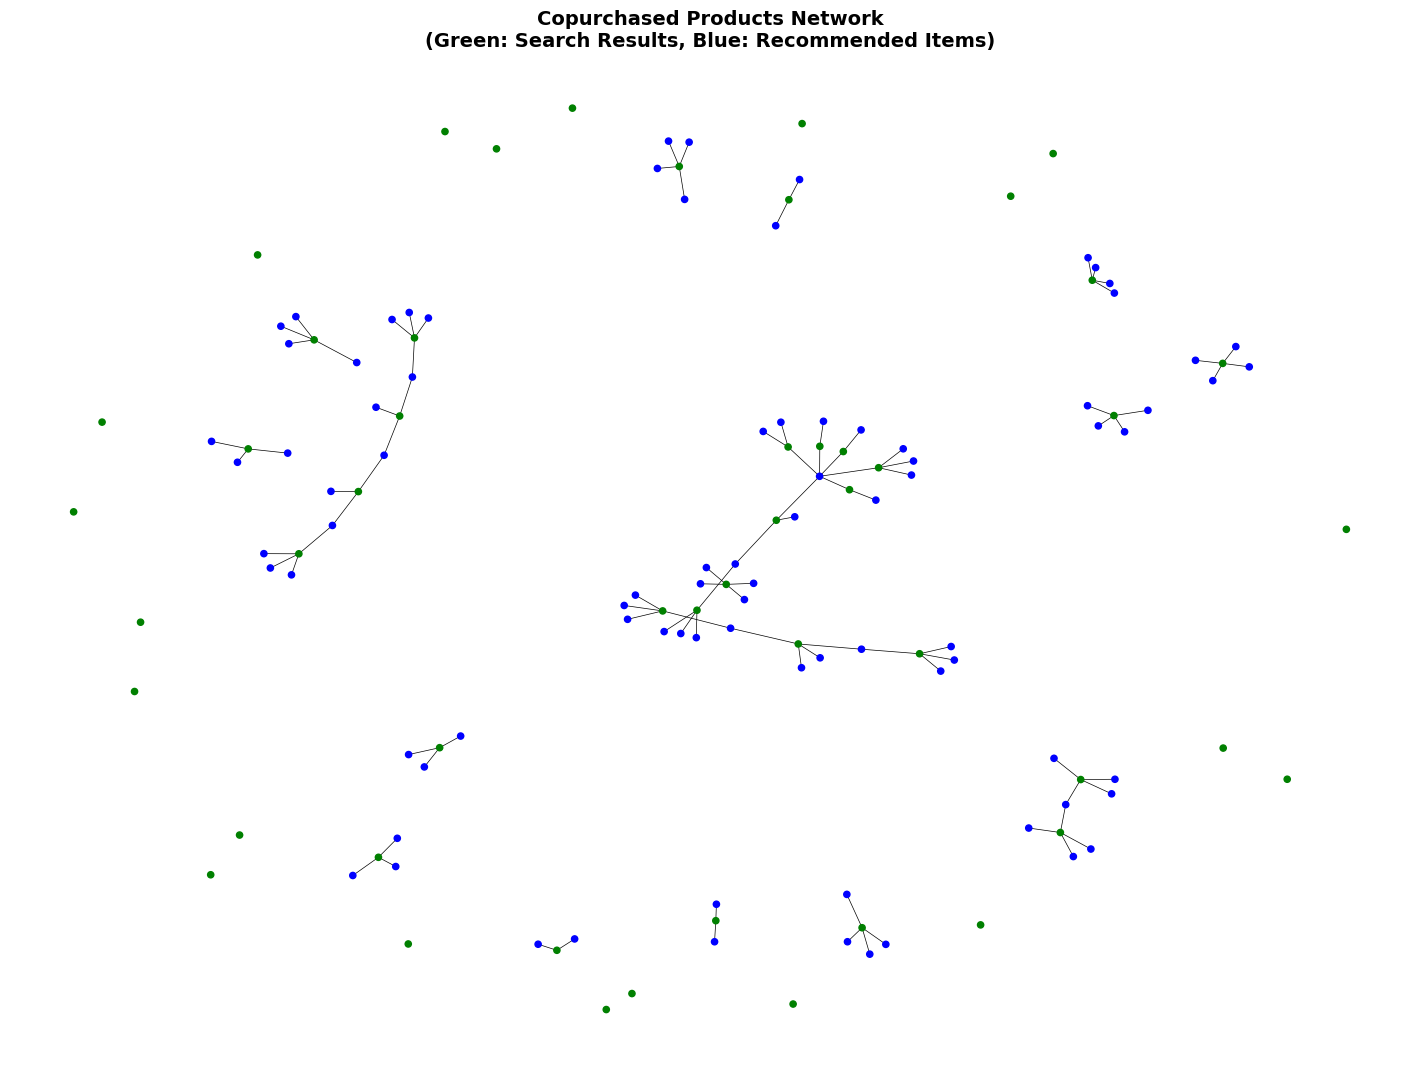

In [92]:
def is_origin_product_url(url: str):
    return url in [listing.url for listing in noon_listings]


plt.figure(figsize=(14, 10))
nx.draw(
    noon_product_graph,
    node_size=20,
    width=0.5,
    node_color=[
        "green" if is_origin_product_url(url) else "blue"
        for url in noon_product_graph.nodes
    ],
)
plt.title(
    "Copurchased Products Network\n(Green: Search Results, Blue: Recommended Items)",
    fontsize=14,
    fontweight="bold",
)
plt.savefig("visualisations/03_copurchased_network.png", dpi=300, bbox_inches="tight")
plt.show()

#### Relationship betweeb Price, Rating and Recommendation Cuont of Copurchased Products

Bellow is the data for copurchased products.

In [93]:
listing_to_dataframe(copruchased_product_url_map.values())

,name,url,image,price_type,price,price_range,vendor,subvendor,rating,review_count
0,"MacBook Air MGN63 With 13 Inch Display, M1 Chi...",https://www.noon.com/egypt-en/product/N4196461...,https://f.nooncdn.com/p/pnsku/N41964615A/45/_/...,discrete,38944.99,None,Noon,dtechstore,4.6,None
1,Laptop Backpack Large Capacity School Bag USB ...,https://www.noon.com/egypt-en/laptop-backpack-...,https://f.nooncdn.com/p/pzsku/Z69227260D25835A...,discrete,580.00,None,Noon,ATA Company,4.5,None
2,MX Master 3S Wireless Performance Mouse With U...,https://www.noon.com/egypt-en/mx-master-3s-wir...,https://f.nooncdn.com/p/v1657780300/N53335896A...,discrete,5999.00,None,Noon,Dokkan Tech,4.8,None
3,Redmi Note 15 Dual SIM 4G Black 8G RAM 256GB w...,https://www.noon.com/egypt-en/redmi-note-15-du...,https://f.nooncdn.com/p/pnsku/N70270908V/45/_/...,discrete,13999.00,None,Noon,Souq Store,4.3,None
4,(Upgraded Version) Envy x360 Convertible 2-In-...,https://www.noon.com/egypt-en/product/N7015819...,https://f.nooncdn.com/p/pnsku/N70158196V/45/_/...,discrete,37999.00,None,Noon,Egypt Laptop,5.0,None
...,...,...,...,...,...,...,...,...,...,...
80,"Wireless, Bluetooth Gaming Mouse, Silent Click...",https://www.noon.com/egypt-en/wireless-bluetoo...,https://f.nooncdn.com/p/37ede85c7cfa5f6da16c81...,discrete,250.00,None,Noon,,4.0,None
81,"FreeClip 2 Wireless Earphones, Bluetooth Earbu...",https://www.noon.com/egypt-en/freeclip-2-wirel...,https://f.nooncdn.com/p/pnsku/N70267689V/45/_/...,discrete,9999.00,None,Noon,,4.6,None
82,MacBook Pro MDE44 | 14 Inch Display | Apple M5...,https://www.noon.com/egypt-en/product/N7024838...,https://f.nooncdn.com/p/pnsku/N70248383V/45/_/...,discrete,98837.60,None,Noon,,4.5,None
83,Magic Mouse Multi-Touch Surface Black,https://www.noon.com/egypt-en/magic-mouse-mult...,https://f.nooncdn.com/p/v1662442444/N53348294A...,discrete,6998.95,None,Noon,,4.0,None


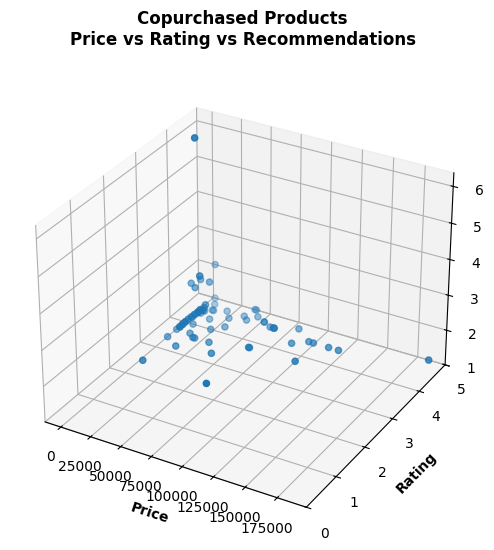

In [94]:
node_degrees= noon_product_graph.degree()

cpp_df = listing_to_dataframe([
    listing
    for listing in copruchased_product_url_map.values()
    if not is_origin_product_url(listing.url)])

cpp_df["num_of_recommendations"] = cpp_df["url"].map(lambda url : node_degrees[url])
        
fig = plt.figure(figsize=(6, 10))
ax = fig.add_subplot(projection='3d')

ax.scatter(cpp_df["price"], cpp_df["rating"], cpp_df["num_of_recommendations"])

ax.set_xlabel("Price", fontweight='bold')
ax.set_ylabel("Rating", fontweight='bold')
ax.set_ylim(0, 5)
ax.set_zlabel("# of Recommendations", labelpad=20, fontweight='bold')
ax.set_zlim(bottom=1)
ax.set_title("Copurchased Products\nPrice vs Rating vs Recommendations", fontsize=12, fontweight='bold', pad=20)
plt.savefig("visualisations/04_copurchased_3d_scatter.png", dpi=300, bbox_inches='tight')

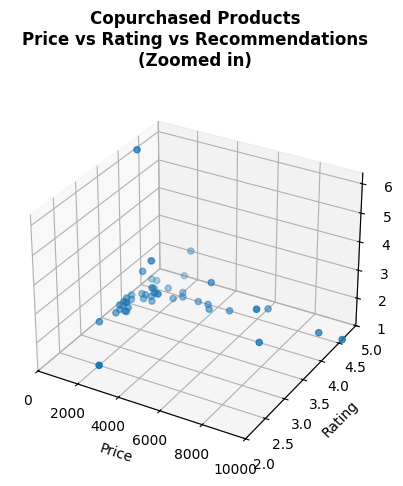

In [95]:
cpp_df_zoomed = cpp_df[(cpp_df["price"] >= 0) & (cpp_df["price"] <= 10000)]

fig = plt.figure()
ax = fig.add_subplot(projection="3d")

ax.scatter(
    cpp_df_zoomed["price"],
    cpp_df_zoomed["rating"],
    cpp_df_zoomed["num_of_recommendations"],
)

ax.set_title(
    "Copurchased Products\nPrice vs Rating vs Recommendations\n(Zoomed in)",
    fontsize=12,
    fontweight="bold",
    pad=20,
)

ax.set_xlabel("Price")
ax.set_xlim(0, 10000)

ax.set_ylabel("Rating")
ax.set_ylim(2, 5)

ax.set_zlabel("# of Recommendations")
ax.set_zlim(bottom=1)
plt.savefig("visualisations/05_copurchased_3d_scatter_zoomed.png", dpi=300, bbox_inches='tight')